# Modelo Red Neuronal con datos de viajes por minuto entre estaciones

Igual que el 7_5 pero con SMOTE y stratify

In [ ]:
version = "7_6_fine_tunning_SMOTE"

In [7]:
import pickle
import pandas as pd
import numpy as np
import json

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [ ]:
# with open("../../data/normalized/df_normalized.pk1", "rb") as f:
with open("../../data/df_normalized_dayOfYear.pk1", "rb") as f:
    df_data = pickle.load(f)

In [9]:
df_data.dtypes

started_at                     datetime64[ns]
ride_id                                object
year                                    int64
event                                    bool
rideable_type_classic_bike               bool
rideable_type_docked_bike                bool
rideable_type_electric_bike              bool
member_casual_bool                       bool
day_type_Holiday                         bool
day_type_Normal                          bool
day_type_Weekend                         bool
temp_std                              float64
wind_std                              float64
rel_humidity_std                      float64
precipitation_std                     float64
snow_depth_std                        float64
start_station_idx                       int64
end_station_idx                         int64
hour_sin                              float64
hour_cos                              float64
month_sin                             float64
month_cos                         

In [10]:
# Se redonde al minuto mas cercano
df_data["started_minute"] = df_data["started_at"].dt.round("min")

In [11]:
df_agg = df_data.groupby([
    "start_station_idx",
    "end_station_idx",
    "started_minute"
]).agg(
    n_viajes=("ride_id", "count"),
    year=("year", "first"),
    temp_std=("temp_std", "first"),
    wind_std=("wind_std", "first"),
    rel_humidity_std=("rel_humidity_std", "first"),
    precipitation_std=("precipitation_std", "first"),
    snow_depth_std=("snow_depth_std", "first"),
    hour_sin=("hour_sin", "first"),
    hour_cos=("hour_cos", "first"),
    month_sin=("month_sin", "first"),
    month_cos=("month_cos", "first"),
    event=("event", "any"),  # True si al menos un dato es true
    normal_day=("day_type_Normal", "any"),  # True si al menos un dato es true
    weekend_day=("day_type_Weekend", "any"),  # True si al menos un dato es true
    holiday_day=("day_type_Holiday", "any"),  # True si al menos un dato es true
    doy_sin=("doy_sin", "first"),
    doy_cos=("doy_cos", "first"),
    #member_casual=("member_casual_bool", "any"),  # True si al menos un dato es true
    #classic_bike=("rideable_type_classic_bike", "any"),  # True si al menos un dato es true
    #docked_bike=("rideable_type_docked_bike", "any"),  # True si al menos un dato es true
    #electric_bike=("rideable_type_electric_bike", "any"),  # True si al menos un dato es true
    #duration_min_mean=("duration_min", "mean"),
).reset_index()

In [12]:
df_agg.shape

(9073410, 20)

In [13]:
df_agg.describe()

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
count,9.073410e+06,9.073410e+06,9073410,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06,9.073410e+06
mean,1.451035e+03,1.451958e+03,2023-03-15 06:23:51.479779072,1.048204e+00,2.022696e+03,-1.495024e-02,-1.812192e-03,8.774936e-03,4.883809e-05,1.967412e-03,-3.315338e-01,-2.758742e-01,5.239540e-02,-2.769533e-01,-2.239218e-02,-2.820444e-01
min,0.000000e+00,0.000000e+00,2022-01-01 00:00:00,1.000000e+00,2.022000e+03,-4.191219e+00,-1.996051e+00,-2.519273e+00,-9.970427e-02,-5.614845e-02,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-9.999907e-01,-9.999630e-01
25%,1.358000e+03,1.358000e+03,2022-08-06 17:06:00,1.000000e+00,2.022000e+03,-7.493464e-01,-6.917960e-01,-7.628922e-01,-9.970427e-02,-5.614845e-02,-9.362641e-01,-8.029042e-01,-5.000000e-01,-8.660254e-01,-7.638886e-01,-8.475409e-01
50%,1.447000e+03,1.448000e+03,2023-04-13 19:23:00,1.000000e+00,2.023000e+03,1.895027e-01,-8.000990e-02,1.485145e-02,-9.970427e-02,-5.614845e-02,-6.025698e-01,-3.916012e-01,1.224647e-16,-5.000000e-01,-2.581844e-02,-4.749511e-01
75%,1.565000e+03,1.565000e+03,2023-09-10 20:57:00,1.000000e+00,2.023000e+03,7.707278e-01,6.198615e-01,7.945084e-01,-9.970427e-02,-5.614845e-02,2.005080e-01,1.192704e-01,8.660254e-01,6.123234e-17,6.994583e-01,2.261157e-01
max,1.911000e+03,1.911000e+03,2024-06-01 00:00:00,9.000000e+00,2.024000e+03,2.175728e+00,5.576328e+00,2.359562e+00,6.945283e+01,7.287764e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.999907e-01,1.000000e+00
std,2.191965e+02,2.176947e+02,NaN,2.348621e-01,6.859159e-01,1.003718e+00,1.000607e+00,9.993908e-01,9.976954e-01,1.017557e+00,6.781692e-01,5.950339e-01,7.215361e-01,6.324060e-01,7.207822e-01,6.327896e-01


In [14]:
df_agg.iloc[10000:10010]

,start_station_idx,end_station_idx,started_minute,n_viajes,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day,doy_sin,doy_cos
10000,5,1362,2022-06-21 00:57:00,1,2022,1.595537,0.115036,-1.872588,-0.099704,-0.056148,0.246788,0.969070,5.000000e-01,-8.660254e-01,False,True,False,False,0.179767,-0.983709
10001,5,1362,2022-06-30 23:12:00,1,2022,1.607251,1.549199,-1.694654,-0.099704,-0.056148,-0.208836,0.977951,5.000000e-01,-8.660254e-01,False,True,False,False,0.025818,-0.999667
10002,5,1362,2022-07-06 21:22:00,1,2022,0.976758,0.449277,0.293232,-0.099704,-0.056148,-0.636639,0.771162,1.224647e-16,-1.000000e+00,False,True,False,False,-0.077386,-0.997001
10003,5,1362,2022-07-10 10:15:00,1,2022,0.056858,-1.307653,1.096805,-0.099704,-0.056148,0.442419,-0.896808,1.224647e-16,-1.000000e+00,True,False,True,False,-0.145799,-0.989314
10004,5,1362,2022-07-14 18:18:00,1,2022,1.028438,-0.764584,-0.615571,-0.099704,-0.056148,-0.996974,0.077734,1.224647e-16,-1.000000e+00,False,True,False,False,-0.213521,-0.976938
10005,5,1362,2022-08-13 14:58:00,1,2022,0.801047,0.344502,-0.797331,-0.099704,-0.056148,-0.700857,-0.713301,-5.000000e-01,-8.660254e-01,False,False,True,False,-0.668064,-0.744104
10006,5,1362,2022-08-22 11:15:00,1,2022,0.212242,-0.741637,1.378055,-0.099704,-0.056148,0.196731,-0.980458,-5.000000e-01,-8.660254e-01,False,True,False,False,-0.774884,-0.632103
10007,5,1362,2022-09-03 13:02:00,1,2022,0.660994,-0.630728,0.861473,-0.099704,-0.056148,-0.266257,-0.963902,-8.660254e-01,-5.000000e-01,True,False,True,False,-0.888057,-0.459733
10008,5,1362,2022-09-20 17:01:00,1,2022,1.279257,0.561730,-0.131514,-0.099704,-0.056148,-0.966768,-0.255657,-8.660254e-01,-5.000000e-01,False,True,False,False,-0.982927,-0.183998
10009,5,1362,2022-10-04 08:27:00,1,2022,-0.664936,-1.996051,0.989662,-0.099704,-0.056148,0.800339,-0.599548,-1.000000e+00,-1.836970e-16,False,True,False,False,-0.998435,0.055917


In [15]:
df_agg['n_viajes'].value_counts(normalize=False)

n_viajes
1    8671457
2     372173
3      24990
4       4098
5        565
6        103
7         19
8          4
9          1
Name: count, dtype: int64

Claramente hay un desajuste de datos

## Se divide la cantidad de viajes 1 en varias subclases

In [16]:
df_class_1 = df_agg[df_agg['n_viajes'] == 1]

In [ ]:
with open("../../data/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
num_stations = len(le_station.classes_)

In [18]:
df_class_1 = df_agg[df_agg['n_viajes'] == 1].copy()

def assign_subclass(row):
    if row['start_station_idx'] < (num_stations / 2):
        return 1  # Estaciones "bajas"
    else:
        # Estaciones "altas", subdividir por hora
        h = row['started_minute'].hour
        if h <= 10:
            return 2
        elif h <= 17:
            return 3
        else:
            return 4

df_agg.loc[df_class_1.index, 'subclass'] = df_class_1.apply(assign_subclass, axis=1)

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())


subclass
3.0    4163596
4.0    2190680
2.0    2172307
1.0     144874
Name: count, dtype: int64


### Se añaden el resto de clases (viajes) que faltan

Se mueve el resto de clases

In [19]:
mask = df_agg['n_viajes'] > 1
df_agg.loc[mask, 'subclass'] = df_agg.loc[mask, 'n_viajes'] + 3

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())


subclass
3.0     4163596
4.0     2190680
2.0     2172307
5.0      372173
1.0      144874
6.0       24990
7.0        4098
8.0         565
9.0         103
10.0         19
11.0          4
12.0          1
Name: count, dtype: int64


Se agrupan los viajes 8, 9 y 7 en una sola clase

In [ ]:
mask = df_agg['subclass'] >= 5
df_agg.loc[mask, 'subclass'] = 5

# Revisar conteo por subclase
print(df_agg['subclass'].value_counts())

subclass
3.0    4163596
4.0    2190680
2.0    2172307
5.0     372173
1.0     144874
6.0      24990
7.0       4098
8.0        692
Name: count, dtype: int64


In [21]:
# convertir a entero
df_agg['subclass'] = df_agg['subclass'].astype(int)

## Simulación de datos con SMOT de las clases minoritarias

Se intenta no igualar las clases porque no tendria sentido en clases tan desvalanceadas por eso se limita el SMOTE

In [22]:
df_agg.dtypes

start_station_idx             int64
end_station_idx               int64
started_minute       datetime64[ns]
n_viajes                      int64
year                          int64
temp_std                    float64
wind_std                    float64
rel_humidity_std            float64
precipitation_std           float64
snow_depth_std              float64
hour_sin                    float64
hour_cos                    float64
month_sin                   float64
month_cos                   float64
event                          bool
normal_day                     bool
weekend_day                    bool
holiday_day                    bool
doy_sin                     float64
doy_cos                     float64
subclass                      int64
dtype: object

In [23]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from collections import Counter

# --- 1. Separar features y target ---
df = df_agg.copy()

data_raw = df.drop(columns=['started_minute'])  # quitar datetime
y = df['subclass'].astype(int)

print("Antes:", Counter(y))

# --- 3. Ajustar estrategia SMOTE ---
# Como tus clases 7 y 8 tienen muy pocos ejemplos,
# usamos k_neighbors=2 y fijamos targets razonables.

target_sizes = {
    1: 150_000,
    6: 40_000,
    7: 10_000,
    8: 5_000
}

sm = SMOTE(
    sampling_strategy=target_sizes,
    k_neighbors=2,
    random_state=42
)

# --- 4. Aplicar SMOTE ---
data_smote, y_smote = sm.fit_resample(data_raw, y)

print("Después:", Counter(y_smote))

# 4. Reconstruir DataFrame final
df_smote = pd.DataFrame(data_smote, columns=df_agg.columns.drop("started_minute"))
df_smote['subclass'] = y_smote


Antes: Counter({3: 4163596, 4: 2190680, 2: 2172307, 5: 372173, 1: 144874, 6: 24990, 7: 4098, 8: 692})
Después: Counter({3: 4163596, 4: 2190680, 2: 2172307, 5: 372173, 1: 150000, 6: 40000, 7: 10000, 8: 5000})


In [24]:
# Revisar conteo por subclase
print(df_smote['subclass'].value_counts())

subclass
3    4163596
4    2190680
2    2172307
5     372173
1     150000
6      40000
7      10000
8       5000
Name: count, dtype: int64


## Obtención de datos

In [25]:
x_context = df_smote.drop(columns=[
    "n_viajes",
    #"started_minute",
    "start_station_idx",
    "end_station_idx",
    "subclass",
])

x_start = df_smote[[
    "start_station_idx",
]]

x_end = df_smote[[
    "end_station_idx",
]]

y = df_smote["subclass"]

In [26]:
x_context.head()

,year,temp_std,wind_std,rel_humidity_std,precipitation_std,snow_depth_std,hour_sin,hour_cos,month_sin,month_cos,event,normal_day,weekend_day,holiday_day,doy_sin,doy_cos
0,2022,-1.379839,1.021427,1.326397,-0.099704,-0.056148,-0.416215,-0.909266,0.500000,0.866025,False,False,False,True,0.661635,0.749826
1,2022,-0.612834,-0.276355,-0.807078,-0.099704,-0.056148,-0.717569,-0.696487,0.866025,0.500000,False,False,True,False,0.891981,0.452072
2,2022,-1.156238,4.113864,0.687365,-0.099704,-0.056148,0.281155,-0.959662,0.866025,0.500000,False,False,True,False,0.899631,0.436651
3,2022,-0.424108,-0.883141,-1.019270,-0.099704,-0.056148,-0.972183,-0.234223,0.866025,0.500000,False,False,True,False,0.977848,0.209315
4,2022,-0.410327,-0.825775,-1.038403,-0.099704,-0.056148,-0.976781,-0.214238,0.866025,0.500000,False,False,True,False,0.977848,0.209315


In [27]:
x_context.dtypes

year                   int64
temp_std             float64
wind_std             float64
rel_humidity_std     float64
precipitation_std    float64
snow_depth_std       float64
hour_sin             float64
hour_cos             float64
month_sin            float64
month_cos            float64
event                   bool
normal_day              bool
weekend_day             bool
holiday_day             bool
doy_sin              float64
doy_cos              float64
dtype: object

In [28]:
x_context.shape

(9103756, 16)

In [29]:
x_start.head()

,start_station_idx
0,0
1,0
2,0
3,0
4,0


In [30]:
x_end.head()

,end_station_idx
0,0
1,0
2,0
3,0
4,0


In [31]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: subclass, dtype: int64

## Se continua diviendo los datos

In [ ]:
with open("../../data/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1912

In [35]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: subclass, dtype: int64

In [36]:
# El target empieza en 1 → lo pasamos a 0
y_cls = y - 1

num_classes = y_cls.max() + 1
print("Clases totales:", num_classes)

Clases totales: 8


In [37]:
x_context.dtypes

year                   int64
temp_std             float64
wind_std             float64
rel_humidity_std     float64
precipitation_std    float64
snow_depth_std       float64
hour_sin             float64
hour_cos             float64
month_sin            float64
month_cos            float64
event                   bool
normal_day              bool
weekend_day             bool
holiday_day             bool
doy_sin              float64
doy_cos              float64
dtype: object

In [38]:
from sklearn.model_selection import train_test_split

x_ctx_train, x_ctx_test, x_start_train, x_start_test, x_end_train, x_end_test, y_train, y_test = \
    train_test_split(x_context, x_start, x_end, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

x_ctx_train, x_ctx_val, x_start_train, x_start_val, x_end_train, x_end_val, y_train, y_val = \
    train_test_split(x_ctx_train, x_start_train, x_end_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


## Se calcula class_weight para evitar colpaso por dominación de la clase 1

In [53]:
y_train.head()

9018283    3
4793032    1
5370276    2
9050003    1
3520831    2
Name: subclass, dtype: int64

In [54]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes_present = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)

class_weights = {i: w for i, w in zip(classes_present, class_weights)}
print(class_weights)


{np.int64(0): np.float64(7.586462239583334), np.int64(1): np.float64(0.5238530874445074), np.int64(2): np.float64(0.27331400471797596), np.int64(3): np.float64(0.5194594821099331), np.int64(4): np.float64(3.0576446324362903), np.int64(5): np.float64(28.4492333984375), np.int64(6): np.float64(113.79693359375), np.int64(7): np.float64(227.5938671875)}


In [55]:
print("Clases en train:", np.unique(y_train))
print("Clases totales:", np.arange(num_classes))


Clases en train: [0 1 2 3 4 5 6 7]
Clases totales: [0 1 2 3 4 5 6 7]


## Se continua con la creación del modelo

### Se aumenta la normalización porque se ha observado que puede haber overfitting

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.optimizers import Adam
import numpy as np

num_stations = len(le_station.classes_)
num_features = x_context.shape[1]

def build_model(hp):
    embed_dim = hp.Choice("embed_dim", [int(np.sqrt(num_stations)),
                                        int(1.5*np.sqrt(num_stations)),
                                        int(2*np.sqrt(num_stations))])

    l2_reg = hp.Choice("l2_reg", [1e-5, 1e-4, 1e-3])
    drop_rate = hp.Choice("drop_rate", [0.1, 0.3, 0.5])
    lr = hp.Choice("lr", [1e-3, 3e-4, 1e-4])

    input_start = Input(shape=(1,), name="start_station")
    input_end = Input(shape=(1,), name="end_station")
    input_context = Input(shape=(num_features,), name="context")

    emb_s = layers.Embedding(num_stations, embed_dim,
                             embeddings_regularizer=regularizers.l2(l2_reg))(input_start)
    emb_e = layers.Embedding(num_stations, embed_dim,
                             embeddings_regularizer=regularizers.l2(l2_reg))(input_end)

    x = layers.Concatenate()([
        layers.Flatten()(emb_s),
        layers.Flatten()(emb_e),
        input_context
    ])

    for units in [128, 64, 32]:
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.LeakyReLU()(x)
        x = layers.Dropout(drop_rate)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)

    model = Model([input_start, input_end, input_context], out)

    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 44)     │     84,128 │ start_station[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 44)     │     84,128 │ end_station[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 44)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 44)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 104)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     13,440 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64)        │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32)        │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │        264 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 192,296 (751.16 KB)

 Trainable params: 192,296 (751.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=15,
    executions_per_trial=2,
    directory="kt_tuning",
    project_name="stations_context_bayes"
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

#Se buscan las mejores variables
tuner.search(
    {
        "start_station": x_start_train,
        "end_station": x_end_train,
        "context": x_ctx_train
    },
    y_train,
    validation_data=(
        {
            "start_station": x_start_val,
            "end_station": x_end_val,
            "context": x_ctx_val
        },
        y_val
    ),
    epochs=30,
    batch_size=8192,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
22760/22760 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 0.1849 - loss: 11.9779 - val_accuracy: 0.4537 - val_loss: 1.6298
Epoch 2/50
22760/22760 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - accuracy: 0.5336 - loss: 1.5479 - val_accuracy: 0.7379 - val_loss: 1.1036
Epoch 3/50
22760/22760 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 0.6877 - loss: 1.4271 - val_accuracy: 0.7354 - val_loss: 1.1568
Epoch 4/50
22760/22760 ━━━━━━━━━━━━━━━━━━━━ 55s 2ms/step - accuracy: 0.7249 - loss: 1.3951 - val_accuracy: 0.7921 - val_loss: 1.0307
Epoch 5/50
22760/22760 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - accuracy: 0.7429 - loss: 1.3775 - val_accuracy: 0.8061 - val_loss: 1.0604
Epoch 6/50
22760/22760 ━━━━━━━━━━━━━━━━━━━━ 74s 3ms/step - accuracy: 0.7552 - loss: 1.3605 - val_accuracy: 0.6797 - val_loss: 1.1845
Epoch 7/50
22760/22760 ━━━━━━━━━━━━━━━━━━━━ 74s 3ms/step - accuracy: 0.7643 - loss: 1.3503 - val_accuracy: 0.6881 - val_loss: 1.2059
Epoch 8/50
22760/22760 ━━━━━━━━━━━━━━━━━━━━ 73s 3ms/step - accuracy:

In [ ]:
# Se obtienen los mejores hiperparametros
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Mejores hiperparametros:")
for k, v in best_hp.values.items():
    print(f"{k}: {v}")

# Se reentrena el mejor modelo
best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    {
        "start_station": x_start_train,
        "end_station": x_end_train,
        "context": x_ctx_train
    },
    y_train,
    validation_data=(
        {
            "start_station": x_start_val,
            "end_station": x_end_val,
            "context": x_ctx_val
        },
        y_val
    ),
    epochs=60,
    batch_size=8192,
    callbacks=callbacks,
    verbose=1
)

In [58]:
import matplotlib.pyplot as plt

def show_history(history, model_name: str):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))  # 2 filas, 1 columna

    # Pérdida (loss)
    ax1.plot(history.history['loss'],     label='Training Loss',  color='green')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='blue')
    ax1.set_title('Loss evolution')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Precisión (accuracy)
    ax2.plot(history.history['accuracy'],     label='Training Accuracy',  color='green')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
    ax2.set_title('Accuracy evolution')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # Título global
    fig.suptitle(model_name, fontsize=16)

    # Ajustar márgenes
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

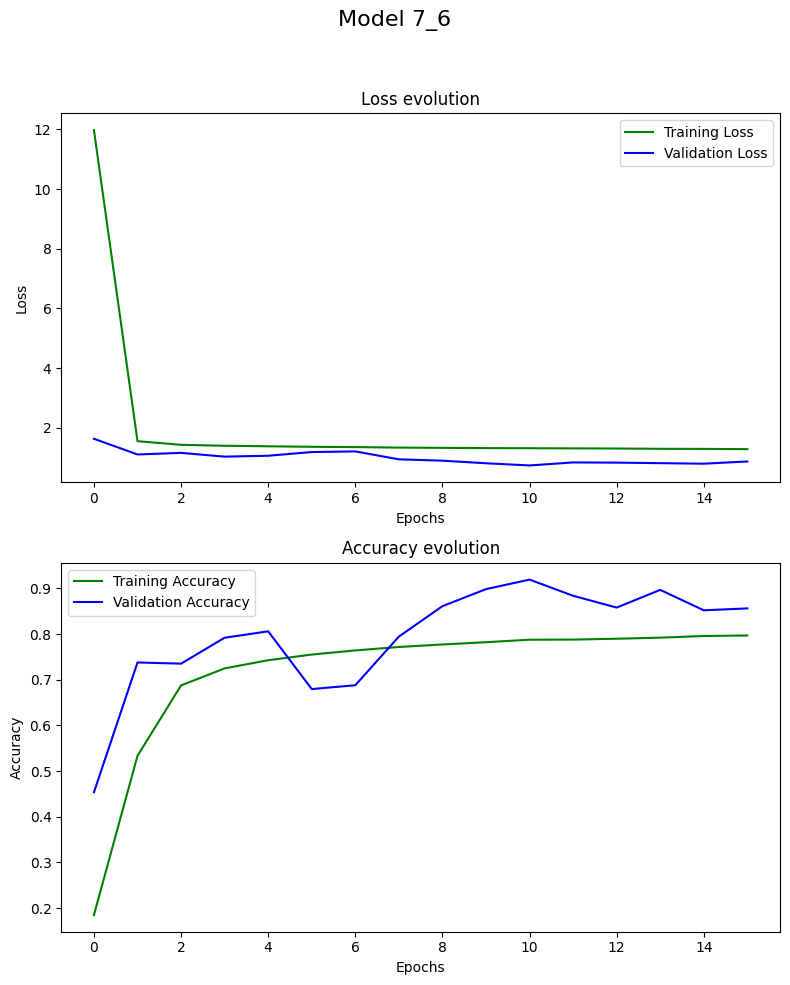

In [59]:
show_history(history, f"Model {version}")

In [ ]:
model.save(f"model_{version}.keras")

with open(f'history_{version}.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
with open('history_{version}.json', "r", encoding="utf-8") as f:
    history = json.load(f)
    
# Mejor época según val_accuracy
best_epoch = np.argmin(history['val_loss'])
best_train_acc = history['accuracy'][best_epoch]
best_val_acc = history['val_accuracy'][best_epoch]
best_val_loss = history['val_loss'][best_epoch]

print("Mejor época:", best_epoch+1)
print("Mejor train_accuracy:", best_train_acc)
print("Mejor val_accuracy:", best_val_acc)
print("Mejor val_loss:", best_val_loss)

Mejor época: 11
Mejor train_accuracy: 0.7877570390701294
Mejor val_accuracy: 0.9194110035896301
Mejor val_loss: 0.7349809408187866


## Evaluación del modelo

In [ ]:
# Evaluacion del modelo
test_metrics = best_model.evaluate(
    {
        "start_station": x_start_test,
        "end_station": x_end_test,
        "context": x_ctx_test
    },
    y_test,
    verbose=0
)

56899/56899 - 53s - 923us/step - accuracy: 0.9194 - loss: 0.7354
Test metrics (loss, accuracy): [0.7354465126991272, 0.9194393157958984]


# Prediccion del modelo

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(f"model_{version}.keras")

In [49]:
# Predicciones como probabilidades
y_pred_probs = model.predict({
    'start_station': x_start,
    'end_station': x_end,
    'context': x_context
}, batch_size=256)

print("Shape de predicciones:", y_pred_probs.shape)
# (num_ejemplos, num_classes)


35562/35562 ━━━━━━━━━━━━━━━━━━━━ 28s 790us/step
Shape de predicciones: (9103756, 8)


In [50]:
# Elegimos la clase con mayor probabilidad



y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Clases predichas:", np.unique(y_pred_classes))


Clases predichas: [0 1 2 3 4 5 6 7]


In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls, y_pred_classes)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls, y_pred_classes))

# Matriz de confusión
cm = confusion_matrix(y_cls, y_pred_classes)
print(cm)


Accuracy test: 0.9195359585647945
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    150000
           1       0.96      0.98      0.97   2172307
           2       0.95      0.94      0.95   4163596
           3       0.88      0.99      0.93   2190680
           4       0.11      0.00      0.01    372173
           5       0.02      0.02      0.02     40000
           6       0.01      0.01      0.01     10000
           7       0.04      0.48      0.08      5000

    accuracy                           0.92   9103756
   macro avg       0.49      0.55      0.49   9103756
weighted avg       0.89      0.92      0.90   9103756

[[ 149643      57      57      53      40      87      21      42]
 [    371 2122033   10037   28539    1016    2966      22    7323]
 [    212   47130 3923904  113706    6419   32525   16248   23452]
 [    396     620    3468 2171442     408     798    1449   12099]
 [   3890   46868  178590  131547    1024    44

## Se elimina la extensión de la categoría 1

In [52]:
y_cls.unique()

array([0, 4, 5, 6, 7, 2, 3, 1])

In [53]:
np.unique(y_pred_classes)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [54]:
conteo_clases = y_cls.value_counts()
print(conteo_clases)

subclass
2    4163596
3    2190680
1    2172307
4     372173
0     150000
5      40000
6      10000
7       5000
Name: count, dtype: int64


In [55]:
mapping = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 2,
    5: 2,
    6: 2,
    7: 2
}

y_cls_real = y_cls.map(mapping)
y_pred_real = np.vectorize(lambda x: mapping.get(x, x))(y_pred_classes)

print(np.unique(y_pred_real))
print(y_cls_real.unique())


[1 2]
[1 2]


In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_cls_real, y_pred_real)
print("Accuracy test:", acc)

# Reporte detallado por clase
print(classification_report(y_cls_real, y_pred_real))

# Matriz de confusión
cm = confusion_matrix(y_cls_real, y_pred_real)
print(cm)

Accuracy test: 0.9440733033706088
              precision    recall  f1-score   support

           1       0.95      0.99      0.97   8676583
           2       0.18      0.05      0.08    427173

    accuracy                           0.94   9103756
   macro avg       0.57      0.52      0.53   9103756
weighted avg       0.92      0.94      0.93   9103756

[[8571668  104915]
 [ 404228   22945]]


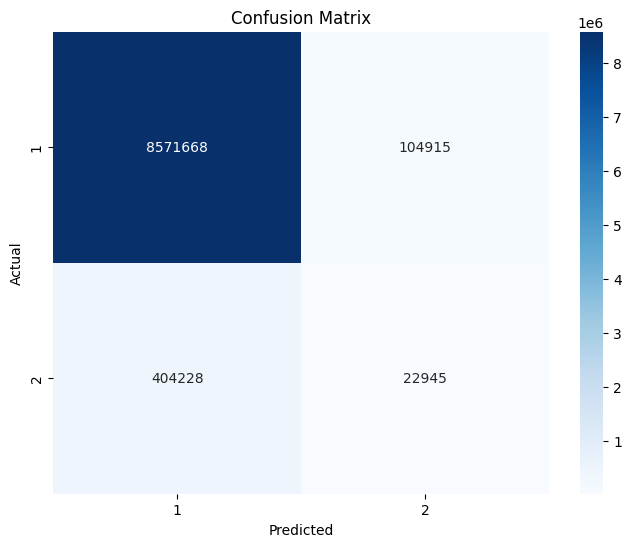

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización con heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=set(y_cls_real), yticklabels=set(y_cls_real))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()